# 12 - Machine Learning: predictive maintenance

**Question this model answers:** which machine is most likely to break
down (unplanned failure) tomorrow? This is the most classic
"Industry 4.0" use case, and the most directly actionable: a ranked
daily list a maintenance team could check every morning.


In [1]:
import sys
sys.path.insert(0, "../machine_learning")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import ml_lib as ml

PROCESSED = "../../datasets/processed"
MODELS = "../../models"
REPORTS = "../../reports"
os.makedirs(MODELS, exist_ok=True)

production = pd.read_csv(f"{PROCESSED}/fact_production_processed.csv", encoding="utf-8-sig", parse_dates=["Date"])
downtime = pd.read_csv(f"{PROCESSED}/fact_downtime_processed.csv", encoding="utf-8-sig", parse_dates=["Date"])


## Step 1: build the daily table (one row per machine x day)

I need a row for **every day**, even days with no failure at all --
the model needs to see what a "normal" day looks like too, not just
failure days.


In [2]:
all_days = pd.date_range(production["Date"].min(), production["Date"].max(), freq="D")
machines = sorted(downtime["MachineId"].unique())

# MultiIndex.from_product creates every machine x day combination
table = pd.MultiIndex.from_product([machines, all_days], names=["MachineId", "Date"]).to_frame(index=False)

daily_failures = downtime[downtime["UnplannedFailure"]].groupby(["MachineId", "Date"]).size().rename("FailureCount")
daily_run_hours = production.groupby(["MachineId", "Date"])["RunTimeHours"].sum().rename("RunHours")
daily_availability = production.groupby(["MachineId", "Date"])["Availability"].mean().rename("AvgAvailability")
machine_process = production.drop_duplicates("MachineId").set_index("MachineId")["Process"]

table = table.merge(daily_failures, on=["MachineId", "Date"], how="left").fillna({"FailureCount": 0})
table = table.merge(daily_run_hours, on=["MachineId", "Date"], how="left").fillna({"RunHours": 0})
table = table.merge(daily_availability, on=["MachineId", "Date"], how="left")
table["Process"] = table["MachineId"].map(machine_process)
table = table.sort_values(["MachineId", "Date"]).reset_index(drop=True)

print(f"Table: {len(table):,} machine-day combinations, {table['MachineId'].nunique()} machines")
table.head()


Table: 6,570 machine-day combinations, 18 machines


,MachineId,Date,FailureCount,RunHours,AvgAvailability,Process
0,HF-001,2025-07-18,2.0,28.386667,0.873863,Hot Foil Stamping
1,HF-001,2025-07-19,0.0,8.470000,1.000000,Hot Foil Stamping
2,HF-001,2025-07-20,0.0,0.000000,NaN,Hot Foil Stamping
3,HF-001,2025-07-21,0.0,19.740000,1.000000,Hot Foil Stamping
4,HF-001,2025-07-22,0.0,23.510000,1.000000,Hot Foil Stamping


## Step 2: history-based features (only looking backward, never forward)

`DaysSinceLastFailure` counts how many days have passed since that
machine's last failure -- resets to 0 every time a new failure happens.
The other features sum/average the last 7 or 14 days, always starting
from the day before (`shift(1)`), never including the day I'm trying
to predict.


In [3]:
by_machine = table.groupby("MachineId")

# counts days since the last failure: every failure (FailureCount > 0)
# resets the count to 0; failure-free days keep incrementing it
table["DaysSinceLastFailure"] = table.groupby("MachineId")["FailureCount"].transform(
    lambda s: s.eq(0).groupby((s > 0).cumsum()).cumcount()
)

table["FailuresTrailing7d"] = by_machine["FailureCount"].transform(
    lambda s: s.shift(1).rolling(7, min_periods=1).sum()
)
table["FailuresTrailing14d"] = by_machine["FailureCount"].transform(
    lambda s: s.shift(1).rolling(14, min_periods=1).sum()
)
table["AvgAvailabilityTrailing7d"] = by_machine["AvgAvailability"].transform(
    lambda s: s.shift(1).rolling(7, min_periods=1).mean()
)
table["RunHoursYesterday"] = by_machine["RunHours"].shift(1)
table["ISOWeekday"] = table["Date"].dt.isocalendar().day.astype(int)

# THE TARGET: was there an unplanned failure TOMORROW? (shift(-1) looks
# forward, only to build the target -- never used as an input feature)
table["FailureTomorrow"] = by_machine["FailureCount"].shift(-1).gt(0).astype(float)

model_data = table.dropna(subset=[
    "FailuresTrailing7d", "FailuresTrailing14d", "AvgAvailabilityTrailing7d", "RunHoursYesterday", "FailureTomorrow"
]).copy()
model_data["FailureTomorrow"] = model_data["FailureTomorrow"].astype(int)

print(f"Model data: {len(model_data):,} rows | "
      f"Positive rate (failure tomorrow): {model_data['FailureTomorrow'].mean():.1%}")


Model data: 6,552 rows | Positive rate (failure tomorrow): 60.8%


## Step 3: train/test split

In [4]:
encoded_model_data = pd.get_dummies(model_data, columns=["Process"], drop_first=True)

feature_columns = [
    "DaysSinceLastFailure", "FailuresTrailing7d", "FailuresTrailing14d",
    "AvgAvailabilityTrailing7d", "RunHoursYesterday", "ISOWeekday",
] + [c for c in encoded_model_data.columns if c.startswith("Process_")]

train, test = ml.split_by_date(encoded_model_data, "Date", test_fraction=0.2)
X_train, y_train = train[feature_columns], train["FailureTomorrow"]
X_test, y_test = test[feature_columns], test["FailureTomorrow"]

print(f"Train: {len(train):,} rows ({y_train.mean():.1%} positive)")
print(f"Test:  {len(test):,} rows ({y_test.mean():.1%} positive)")


Train: 5,241 rows (60.8% positive)
Test:  1,311 rows (60.5% positive)


## Step 4: train the model

In [5]:
model = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

prediction = model.predict(X_test)
probability = model.predict_proba(X_test)[:, 1]

print(ml.classification_metrics(y_test, prediction, probability))
print()
ml.show_classification_report(y_test, prediction, class_names=("No failure", "Failure"))


{'Accuracy': 0.7238749046529367, 'Precision': 0.7386489479512736, 'Recall': 0.8411097099621689, 'F1': 0.7865566037735849, 'ROC_AUC': 0.7181126361454231}

              precision    recall  f1-score   support

  No failure       0.69      0.54      0.61       518
     Failure       0.74      0.84      0.79       793

    accuracy                           0.72      1311
   macro avg       0.71      0.69      0.70      1311
weighted avg       0.72      0.72      0.72      1311

Confusion matrix (rows=actual, columns=predicted):
                   Predicted No failure  Predicted Failure
Actual No failure                   282                236
Actual Failure                      126                667


## Step 5: feature importance

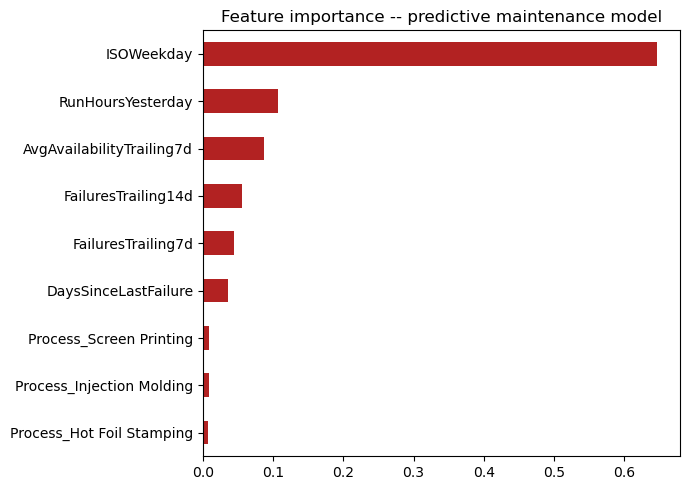

Model saved to ../../models/predictive_maintenance_model.pkl


In [6]:
importance = pd.Series(model.feature_importances_, index=feature_columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
importance.plot(kind="barh", ax=ax, color="firebrick")
ax.set_title("Feature importance -- predictive maintenance model")
plt.tight_layout()
plt.savefig(f"{REPORTS}/41_ml_predictive_maintenance_feature_importance.png", dpi=150)
plt.show()

ml.save_model(
    model, f"{MODELS}/predictive_maintenance_model.pkl",
    feature_cols=feature_columns, target_col="FailureTomorrow", model_name="Random Forest",
    test_metrics=ml.classification_metrics(y_test, prediction, probability),
)
print(f"Model saved to {MODELS}/predictive_maintenance_model.pkl")


## Step 6: today's risk ranking -- the actual deliverable

The list a maintenance supervisor would check every morning: every
machine, sorted by predicted probability of an unplanned failure
today, built from yesterday's data (the most recent day we actually
know for sure).


In [7]:
last_day = table.sort_values("Date").groupby("MachineId").tail(1).copy()
encoded_last_day = pd.get_dummies(last_day, columns=["Process"], drop_first=True)

for column in feature_columns:
    if column not in encoded_last_day.columns:
        encoded_last_day[column] = 0

# advances the history features by one day, using the last known day for each machine
encoded_last_day["DaysSinceLastFailure"] = np.where(
    last_day["FailureCount"] > 0, 0, last_day["DaysSinceLastFailure"] + 1
)
encoded_last_day["FailuresTrailing7d"] = last_day["FailuresTrailing7d"] + last_day["FailureCount"]
encoded_last_day["RunHoursYesterday"] = last_day["RunHours"]

today_risk = model.predict_proba(encoded_last_day[feature_columns])[:, 1]

risk_table = pd.DataFrame({
    "MachineId": last_day["MachineId"].values,
    "Process": last_day["Process"].values,
    "PredictedFailureRiskToday": today_risk,
}).sort_values("PredictedFailureRiskToday", ascending=False)

print(risk_table.head(10).round(3))


   MachineId            Process  PredictedFailureRiskToday
11  ISBM-003       Blow Molding                      0.561
5     IM-002  Injection Molding                      0.545
9     IM-005  Injection Molding                      0.523
0   ISBM-001       Blow Molding                      0.516
14  ISBM-006       Blow Molding                      0.507
12  ISBM-004       Blow Molding                      0.506
7     IM-004  Injection Molding                      0.502
15  ISBM-007       Blow Molding                      0.499
3     HF-002  Hot Foil Stamping                      0.484
10  ISBM-002       Blow Molding                      0.481


## Step 7: export the results

In [8]:
risk_table["GeneratedFrom"] = last_day["Date"].max().date().isoformat()
risk_table.to_csv(f"{PROCESSED}/ml_predictions_predictive_maintenance.csv", index=False, encoding="utf-8-sig")

process_columns = [c for c in test.columns if c.startswith("Process_")]
history = test[["MachineId", "Date", "FailureTomorrow"]].copy()
if process_columns:
    history["Process"] = test[process_columns].idxmax(axis=1).str.replace("Process_", "")
else:
    history["Process"] = np.nan
history["PredictedFailureRisk"] = probability

history.to_csv(f"{PROCESSED}/ml_predictions_predictive_maintenance_history.csv", index=False, encoding="utf-8-sig")
print("Exported ml_predictions_predictive_maintenance.csv and ..._history.csv")


Exported ml_predictions_predictive_maintenance.csv and ..._history.csv


## Summary

`DaysSinceLastFailure` and the 7/14-day trailing failure counts
dominate the feature importance ranking -- exactly what a maintenance
engineer would expect (recent failure frequency is the best short-term
risk predictor, the same intuition behind MTBF, just applied at daily
resolution).
